# Lists in Python

You are supposed to solve the following tasks during classes. Since lists are one of the most common data structures, this knowledge will be necessary later on.

1. Create a function which for a given list of integers verifies whether it contains a sequence of k consecutive numbers.

In [1]:
def has_consecutive(nums: list, k):
    if len(nums) < k: return False

    count = 1

    for i in range(1, len(nums)):
        if nums[i] == nums[i - 1] + 1:
            count += 1
            if count >= k:
                return True
        else:
            count = 1

    return False


lista = [94, 80, 50, 93, 75, 22, 27, 43, 13, 87,
         83, 95, 40, 48, 11, 78, 97, 9, 85, 6,
         96, 1, 2, 37, 74, 49, 91, 58, 26, 57,
         90, 16, 21, 20, 62, 19, 10, 98, 4, 23,
         8, 86, 5, 6, 7, 92, 17, 59, 70, 46]
print(has_consecutive(lista, 3))

True


2. Create a function which for given two lists of strings creates a list containing all possible concatenations of the strings in these lists.

In [2]:
def concat_lists_for_loop(list1: list, list2: list):
    result = []
    for a in list1:
        for b in list2:
            result.append(a + b)
    return result


def concat_lists_list_comprehension(list1: list, list2: list):
    return [a + b for a in list1 for b in list2]


list1 = ["a", "b"]
list2 = ["1", "2", "3"]
wynik = ["a1", "a2", "b1", "b2"]
print(concat_lists_for_loop(list1, list2))
print(concat_lists_list_comprehension(list1, list2))

['a1', 'a2', 'a3', 'b1', 'b2', 'b3']
['a1', 'a2', 'a3', 'b1', 'b2', 'b3']


3. Create a function which removes from a given lists all strings containing polish diacritics ('ąęłóśćżź').

In [3]:
polish_list = ["kot", "pies", "Żaba", "łąka", "dom"]


def remove_polish(strings: list):
    diacritics = 'ąęłóśćńżźĄĘŁÓŚĆŃŻŹ'
    return [s for s in strings if not any(ch in diacritics for ch in s)]


print(remove_polish(polish_list))

['kot', 'pies', 'dom']


4. For a given list of strings consisting of only small and capital letters of the latin alphabet create a function which for each string generates its version such that each capital letter in this string is preceded by a whitespace.

In [4]:
words_list = ["HelloWorld", "PythonCode", "OpenAI"]


def add_whitespace(words: list):
    result = []
    for word in words:
        new_string = ""
        for i, s in enumerate(word):
            if s.isupper() and i != 0:
                new_string += " "
            new_string += s
        result.append(new_string)
    return result


print(add_whitespace(words_list))

['Hello World', 'Python Code', 'Open A I']


# Computational complexity for intermediates

The goal of the last task is to observe how our choices influence the computational complexity. Carry on the following experiment to convince yourself that a proper choice is crucial.

1. Using the library random and comprahension lists from the lecture create a list containing a large number - say, 10,000 - of integers. Let us call it 'aList'. Make sure to fix the random seed to ensure repeatability of the experiment.
2. In the next step, create a copy of this list - let us call it 'bList'. IMPORTANT: 'bList' cannot be a reference to 'aList'. 
3. Find the three greatest elements in 'aList by sorting it.
4. Create your own function finding the three greatest elements in 'bList' without sorting it.
5. Using the module timeit measure the time needed to execute both of these functions. Improve the quality of the measurement by executing it 10 times and taking the mean.
6. Carry out similar experiments for lists of length 50,000, 100,000, 200,000, 300,000, 400,000, 500,000.
7. Illustrate the results in a chart using the module matplotlib.

What is the computational complexity of your method from the point 4? Are you able to tell whether it is better than the complexity of the deafult sorting method based only on the chart?

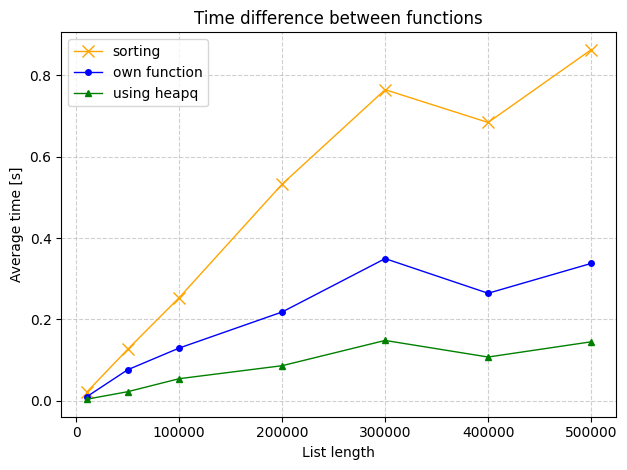

In [5]:
import random
import timeit
import statistics
import heapq
import matplotlib.pyplot as plt

random.seed(100)


def sorting_with_python(lista):
    lista.sort()
    return lista[-3:]


def using_heapq(lista):
    return heapq.nlargest(3, lista)


def find_the_greatest(lista):
    if len(lista) < 3:
        return sorted(lista, reverse=True)
    first, second, third = sorted(lista[:3], reverse=True)

    for i in range(3, len(lista)):
        x = lista[i]
        if x > first:
            first, second, third = x, first, second
        elif x > second:
            second, third = x, second
        elif x > third:
            third = x

    return [first, second, third]


lengths = [10000, 50000, 100000, 200000, 300000, 400000, 500000]
solution1 = []
solution2 = []
solution3 = []

for k in lengths:
    base_list = [random.randint(-1000, 1000) for i in range(k)]
    solution1.append(statistics.mean(timeit.repeat(lambda: sorting_with_python(base_list.copy()), repeat=2, number=10)))
    solution2.append(statistics.mean(timeit.repeat(lambda: find_the_greatest(base_list.copy()), repeat=2, number=10)))
    solution3.append(statistics.mean(timeit.repeat(lambda: using_heapq(base_list.copy()), repeat=2, number=10)))

# Plot the graph to combine above results
plt.plot(lengths, solution1, marker='x', label='sorting', color='orange', ms=8, lw=1)
plt.plot(lengths, solution2, marker='o', label='own function', color='blue', ms=4, lw=1)
plt.plot(lengths, solution3, marker='^', label='using heapq', color='green', ms=4, lw=1)
plt.title('Time difference between functions')
plt.xlabel('List length')
plt.ylabel('Average time [s]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

# sorting_with_python -> O(n log n)
# find_the_greatest -> O(n)
# using_heapq -> O(n log k), k = 3